# The MLE case and the comparison with the five benthic sites

In [1]:
%load_ext autoreload
%autoreload 2

import os
import x4c
import xarray as xr
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
print(x4c.__version__)
os.chdir('/glade/work/fengzhu/Projects/paper-MCO_iCESM/notebooks')

2026.5.26


## Check BWT and d18Osw seasonality

In [2]:
case = {}

dirpath = '/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005'
case['1.5x'] = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

dirpath = '/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005'
case['3x'] = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

>>> case.root_dir: /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["ocn"]["pop.h.nday1"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["rof"]["rtm.h0"] created
>>> case.paths["rof"]["mosart.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["ocn"]["pop.h.nday1"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["rof"]["rtm.h0"] created
>>> case.vns["rof"]["mosart.h0"] created
>>> case.vns["ice"]["cice.h"] created
>>> case.root_dir: /glade/campaign/uni

In [3]:
case['3x'].load('TEMP')
case['3x'].ds['TEMP'].x['TEMP']

>>> case.ds["TEMP"] created


<xarray.DataArray 'TEMP' (time: 600, z_t: 60, nlat: 384, nlon: 320)> Size: 18GB
[4423680000 values with dtype=float32]
Coordinates:
  * time     (time) object 5kB 8951-01-01 00:00:00 ... 9000-12-01 00:00:00
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB ...
    ULAT     (nlat, nlon) float64 983kB ...
    TLONG    (nlat, nlon) float64 983kB ...
    TLAT     (nlat, nlon) float64 983kB ...
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean
    path:          /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseri...
    gw:            <xarray.DataArray 'TAREA' (nlat: 384, nlon: 320)> Size: 98...
    lat:           <xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983...
    lon:           <xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 98...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16

In [4]:
case['3x'].calc('BWT_JJA ~ TEMP|zavg(3e5,None):6,7,8')
case['3x'].calc('BWT_DJF ~ TEMP|zavg(3e5,None):12,1,2')

>>> case.ds["TEMP"] already loaded; to reload, run case.load("TEMP", ..., reload=True).
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]


>>> case.diags["BWT_JJA"] created
>>> case.ds["TEMP"] already loaded; to reload, run case.load("TEMP", ..., reload=True).
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["BWT_DJF"] created


<xarray.DataArray 'BWT_DJF' (time: 51, nlat: 384, nlon: 320)> Size: 25MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(51, 384, 320), dtype=float32)
Coordinates:
  * time     (time) object 408B 8951-02-28 00:00:00 ... 9001-02-28 00:00:00
    ULONG    (nlat, nlon) float64 983kB 343.5 344.8 346.1 ... 326.4 326.7 327.0
    ULAT     (nlat, nlon) float64 983kB -87.53 -87.52 -87.5 ... 72.64 72.64
    TLONG    (nlat, nlon) float64 983kB 341.6 342.9 344.2 ... 326.2 326.5 326.8
    TLAT     (nlat, nlon) float64 983kB -87.73 -87.72 -87.7 ... 72.52 72.52
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Potential Temperature (DJF)
    units:         °C
    grid_loc:      3111
    cell_methods:  time: mean
    path:          /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseri...
    gw:            <xarray.DataArray (nlat: 384, nlon: 320)> Size: 983kB\narr...
    lat:           <xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983...
    lon:           <xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 98...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16

In [5]:
case['3x'].calc('d18Osw_JJA ~ d18Osw|zavg(3e5,None):6,7,8')
case['3x'].calc('d18Osw_DJF ~ d18Osw|zavg(3e5,None):12,1,2')

>>> d18Osw is a supported derived variable.
>>> case.ds["R18O"] created
>>> case.ds["d18Osw"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["d18Osw_JJA"] created
>>> d18Osw is a supported derived variable.
>>> case.ds["R18O"] already loaded; to reload, run case.load("R18O", ..., reload=True).
>>> case.ds["d18Osw"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["d18Osw_DJF"] created


<xarray.DataArray 'd18Osw_DJF' (time: 51, nlat: 384, nlon: 320)> Size: 25MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(51, 384, 320), dtype=float32)
Coordinates:
  * time     (time) object 408B 8951-02-28 00:00:00 ... 9001-02-28 00:00:00
    ULONG    (nlat, nlon) float64 983kB 343.5 344.8 346.1 ... 326.4 326.7 327.0
    ULAT     (nlat, nlon) float64 983kB -87.53 -87.52 -87.5 ... 72.64 72.64
    TLONG    (nlat, nlon) float64 983kB 341.6 342.9 344.2 ... 326.2 326.5 326.8
    TLAT     (nlat, nlon) float64 983kB -87.73 -87.72 -87.7 ... 72.52 72.52
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Sea-water d18O (DJF)
    units:         permil
    grid_loc:      3111
    cell_methods:  time: mean
    path:          /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseri...
    gw:            <xarray.DataArray (nlat: 384, nlon: 320)> Size: 983kB\narr...
    lat:           <xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983...
    lon:           <xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 98...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16
    vn:            d18Osw

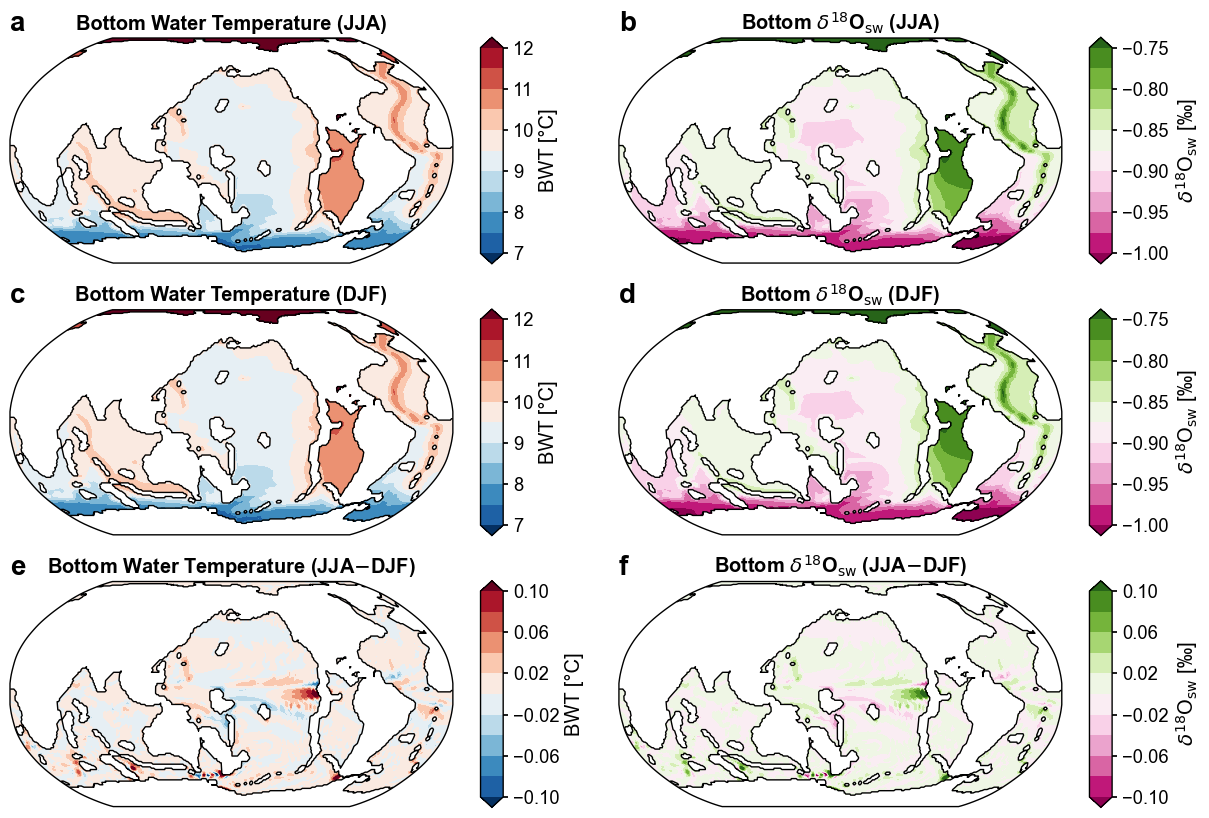

Figure saved at: "../figs/SIFig.02.pdf"


In [7]:
x4c.set_style('journal_spines', font_scale=1.2)
fig, ax = x4c.visual.subplots(
    figsize=(15, 10),
    nrow=3, ncol=2,
    hspace=0.2, wspace=0.1,
    ax_loc={
        'BWT_JJA': (0, 0),
        'd18Osw_JJA': (0, 1),
        'BWT_DJF': (1, 0),
        'd18Osw_DJF': (1, 1),
        'BWT_diff': (2, 0),
        'd18Osw_diff': (2, 1),
    },
    projs={
        'BWT_JJA': 'Robinson',
        'BWT_DJF': 'Robinson',
        'BWT_diff': 'Robinson',
        'd18Osw_JJA': 'Robinson',
        'd18Osw_DJF': 'Robinson',
        'd18Osw_diff': 'Robinson',
    },
    projs_kws={
        'BWT_JJA': {'central_longitude': 180},
        'BWT_DJF': {'central_longitude': 180},
        'BWT_diff': {'central_longitude': 180},
        'd18Osw_JJA': {'central_longitude': 180},
        'd18Osw_DJF': {'central_longitude': 180},
        'd18Osw_diff': {'central_longitude': 180},
    },
    annotation=True,
    annotation_separate=True,
    annotation_kws={
        'BWT_JJA': {'loc_x': 0., 'style': ''},
        'BWT_DJF': {'loc_x': 0., 'style': ''},
        'BWT_diff': {'loc_x': 0., 'style': ''},
        'd18Osw_JJA': {'loc_x': 0., 'style': ''},
        'd18Osw_DJF': {'loc_x': 0., 'style': ''},
        'd18Osw_diff': {'loc_x': 0., 'style': ''},
    },
)

da_BWT_JJA = case['3x'].diags['BWT_JJA'].mean('time').x.regrid()
da_BWT_DJF = case['3x'].diags['BWT_DJF'].mean('time').x.regrid()
da_BWT_diff = da_BWT_JJA -  da_BWT_DJF

da_d18Osw_JJA = case['3x'].diags['d18Osw_JJA'].mean('time').x.regrid()
da_d18Osw_DJF = case['3x'].diags['d18Osw_DJF'].mean('time').x.regrid()
da_d18Osw_diff =  da_d18Osw_JJA - da_d18Osw_DJF

da_BWT_diff.name = 'BWT'
da_d18Osw_diff.name = 'd18Osw'

da_BWT_JJA.x.plot(
    ax=ax['BWT_JJA'],
    title='Bottom Water Temperature (JJA)',
    levels=np.linspace(7, 12, 11),
    cbar_kwargs={
        'label': 'BWT [°C]',
        'ticks': np.linspace(7, 12, 6),
    },
)

da_BWT_DJF.x.plot(
    ax=ax['BWT_DJF'],
    title='Bottom Water Temperature (DJF)',
    levels=np.linspace(7, 12, 11),
    cbar_kwargs={
        'label': 'BWT [°C]',
        'ticks': np.linspace(7, 12, 6),
    },
)

da_BWT_diff.x.plot(
    ax=ax['BWT_diff'],
    title='Bottom Water Temperature (JJA$-$DJF)',
    levels=np.linspace(-0.1, 0.1, 11),
    cbar_kwargs={
        'label': 'BWT [°C]',
        'ticks': np.linspace(-0.1, 0.1, 6),
    },
    cmap='RdBu_r',
)

da_d18Osw_JJA.x.plot(
    ax=ax['d18Osw_JJA'],
    title=r'Bottom $\delta^{18}$O$_{\text{sw}}$ (JJA)',
    levels=np.linspace(-1, -0.75, 11),
    cbar_kwargs={
        'label': r'$\delta^{18}$O$_{\text{sw}}$ [‰]',
    },
    cmap='PiYG',
)

da_d18Osw_DJF.x.plot(
    ax=ax['d18Osw_DJF'],
    title=r'Bottom $\delta^{18}$O$_{\text{sw}}$ (DJF)',
    levels=np.linspace(-1, -0.75, 11),
    cbar_kwargs={
        'label': r'$\delta^{18}$O$_{\text{sw}}$ [‰]',
    },
    cmap='PiYG',
)

da_BWT_diff.x.plot(
    ax=ax['d18Osw_diff'],
    title=r'Bottom $\delta^{18}$O$_{\text{sw}}$ (JJA$-$DJF)',
    levels=np.linspace(-0.1, 0.1, 11),
    cbar_kwargs={
        'label': r'$\delta^{18}$O$_{\text{sw}}$ [‰]',
        'ticks': np.linspace(-0.1, 0.1, 6),
    },
    cmap='PiYG',
)

x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.02.pdf')

## ERSSTv5

In [2]:
import glob
dirpath = '/glade/work/fengzhu/Data/Analyses/ERSSTv5'
paths = sorted(glob.glob(os.path.join(dirpath, f'ersst.v5.201*.nc')))
ds = xr.open_mfdataset(paths, use_cftime=True)
ds

/glade/derecho/scratch/fengzhu/tmp/ipykernel_45457/2632128106.py:4: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(paths, use_cftime=True)
/glade/derecho/scratch/fengzhu/tmp/ipykernel_45457/2632128106.py:4: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(paths, use_cftime=True)
/glade/derecho/scratch/fengzhu/tmp/ipykernel_45457/2632128106.py:4: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeC

<xarray.Dataset> Size: 15MB
Dimensions:  (time: 120, lev: 1, lat: 89, lon: 180)
Coordinates:
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lev      (lev) float64 8B 0.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) object 960B 2010-01-15 00:00:00 ... 2019-12-15 00:00:00
Data variables:
    sst      (time, lev, lat, lon) float32 8MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
    ssta     (time, lev, lat, lon) float32 8MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
Attributes: (12/70)
    Conventions:                     CF-1.6, ACDD-1.3
    metadata_link:                   https://doi.org/10.7289/V5T72FNM
    dataset_doi:                     https://doi.org/10.7289/V5T72FNM
    id:                              gov.noaa.ncdc:C00927
    naming_authority:                gov.noaa.ncei
    title:                           NOAA ERSSTv5 (in situ only)
    ...                              ...
    references:                      Huang et al, 2017: Extended Reconstructe...
    climatology:                     Climatology is based on 1971-2000 SST, X...
    acknowledgment:                  The NOAA Extended Reconstructed Sea Surf...
    history:                         Fri Jan  3 13:14:01 2025: ncap2 -O -s ti...
    NCO:                             netCDF Operators version 4.7.5 (Homepage...
    nco_openmp_thread_number:        1

In [5]:
print(ds['sst'].mean('time').isel(lev=0).min().values)
print(ds['sst'].mean('time').isel(lev=0).max().values)

-1.8
29.93726


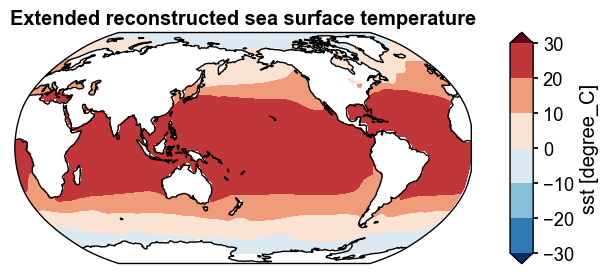

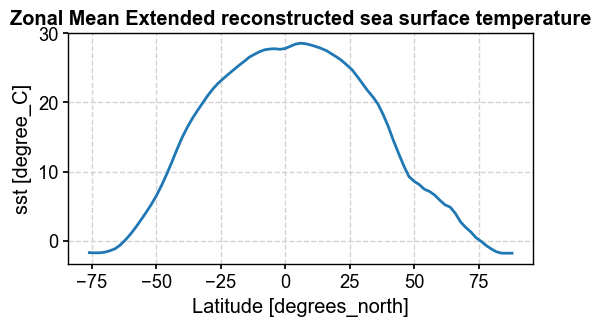

In [ ]:
da_ersstv5 = ds['sst'].mean('time').isel(lev=0).x.zm
fig, ax = ds['sst'].mean('time').isel(lev=0).x.plot()
fig, ax = da_ersstv5.x.plot()

In [ ]:
print(da_ersstv5.sel(lat=slice(-23.5, 23.5)).mean().values)
print(da_ersstv5.sel(lat=slice(-90, -75)).mean().values)
print(da_ersstv5.sel(lat=slice(-90, -70)).mean().values)

27.124048
-1.7138313
-1.7092239


## CRUTS

In [6]:
ds = xr.open_dataset('/glade/work/fengzhu/Data/Analyses/CRUTS/cru_ts4.09.1901.2024.tmp.dat.nc.gz')
ds

<xarray.Dataset> Size: 8GB
Dimensions:  (lon: 720, lat: 360, time: 1488)
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
Data variables:
    tmp      (time, lat, lon) float32 2GB ...
    stn      (time, lat, lon) float64 3GB ...
    mae      (time, lat, lon) float32 2GB ...
    maea     (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.09 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
    history:      Wed  5 Mar 13:28:04 GMT 2025 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [9]:
print(ds['tmp'].mean('time').min().values)
print(ds['tmp'].mean('time').max().values)

-30.631912231445312
30.585737228393555


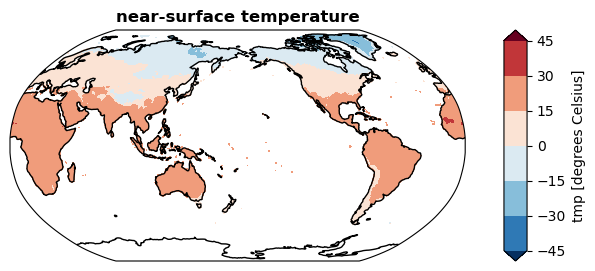

In [7]:
fig, ax = ds['tmp'].mean('time').x.plot()

## PI Control

In [ ]:
dirpath = '/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.PI.tuning.110'
case = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'})

>>> case.root_dir: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.PI.tuning.110
>>> case.path_pattern: comp/proc/tseries/month_1/casename.mdl.h_str.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.vars_info created


In [ ]:
da_pi = case.calc('SST:ann:zm')
da_pi

>>> SST is a supported derived variable.
>>> case.ds["TEMP"] created
>>> Timespan: [4951-01-31 00:00:00, 5000-12-31 00:00:00]
>>> case.diags["SST:ann:zm"] created


<xarray.DataArray 'SST' (time: 50, lat: 180)> Size: 36kB
array([[       nan,        nan,        nan, ..., -1.7663064, -1.7671071,
        -1.7677033],
       [       nan,        nan,        nan, ..., -1.7678374, -1.7665751,
        -1.7658757],
       [       nan,        nan,        nan, ..., -1.7568376, -1.7570914,
        -1.757388 ],
       ...,
       [       nan,        nan,        nan, ..., -1.7771834, -1.7781893,
        -1.7789788],
       [       nan,        nan,        nan, ..., -1.7702339, -1.7701945,
        -1.7702425],
       [       nan,        nan,        nan, ..., -1.7754439, -1.7758772,
        -1.7759093]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
    z_t      float32 4B 500.0
  * time     (time) object 400B 4951-12-31 00:00:00 ... 5000-12-31 00:00:00
Attributes:
    long_name:     Zonal Mean Sea Surface Temperature (Annual)
    units:         °C
    grid_loc:      3111
    cell_methods:  time: mean
    path:          /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e...
    gw:            <xarray.DataArray 'gw' (nlat: 384, nlon: 320)> Size: 983kB...
    lat:           <xarray.DataArray 'lat' (nlat: 384, nlon: 320)> Size: 983k...
    lon:           <xarray.DataArray 'lon' (nlat: 384, nlon: 320)> Size: 983k...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16

In [ ]:
print(da_pi.mean('time').sel(lat=slice(-23.5, 23.5)).mean().values)
print(da_pi.mean('time').sel(lat=slice(-90, -75)).mean().values)
print(da_pi.mean('time').sel(lat=slice(-90, -70)).mean().values)

26.774885
-1.5313016
-1.4878957


In [ ]:
print(26.77+1.5)

28.27
